In [1]:
## Try to use Healthcare NLP: LLMs, Transformers, Datasets to fine-tuned Gemma 2b model

In [2]:
!pip install --upgrade huggingface_hub
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
access_token_read = UserSecretsClient().get_secret("huggingface")
login(token = access_token_read)

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [3]:
!pip install -U keras-nlp
!pip install -U keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.2/465.2 kB 12.9 MB/s eta 0:00:00
  Attempting uninstall: keras-nlp
    Found existing installation: keras-nlp 0.7.0
    Uninstalling keras-nlp-0.7.0:
      Successfully uninstalled keras-nlp-0.7.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.9 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.0.5 which is incompatible.
tensorflowjs 4.16.0 requires packaging~=23.1, but you have packaging 21.3 which is incompatible.


In [4]:
import keras
import keras_nlp
import numpy as np

2024-02-24 15:25:39.025753: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-24 15:25:39.025848: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-24 15:25:39.161904: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
import os

os.environ["KERAS_BACKEND"] = "jax"  # Or "tensorflow" or "torch".
# Avoid memory fragmentation on JAX backend.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]="1.00"

KerasNLP provides implementations of many popular model architectures. In this tutorial, you'll create a model using GemmaCausalLM, an end-to-end Gemma model for causal language modeling. A causal language model predicts the next token based on previous tokens.

Create the model using the from_preset method:

In [6]:
gemma_lm = keras_nlp.models.GemmaCausalLM.from_preset("gemma_2b_en")
# gemma_lm = keras_nlp.models.GemmaCausalLM.from_preset("gemma_7b_en")
# gemma_lm.generate("Keras is a", max_length=30)

# Generate with batched prompts.
# gemma_lm.generate(["Keras is a", "I want to say"], max_length=30)


Attaching 'config.json' from model 'keras/gemma/keras/gemma_2b_en/2' to your Kaggle notebook...
Attaching 'config.json' from model 'keras/gemma/keras/gemma_2b_en/2' to your Kaggle notebook...
Attaching 'model.weights.h5' from model 'keras/gemma/keras/gemma_2b_en/2' to your Kaggle notebook...
Attaching 'tokenizer.json' from model 'keras/gemma/keras/gemma_2b_en/2' to your Kaggle notebook...
Attaching 'assets/tokenizer/vocabulary.spm' from model 'keras/gemma/keras/gemma_2b_en/2' to your Kaggle notebook...
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


In [7]:
gemma_lm.summary()

Preprocessor: "gemma_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Tokenizer (type)                                   ┃                                             Vocab # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma_tokenizer (GemmaTokenizer)                   │                                             256,000 │
└────────────────────────────────────────────────────┴─────────────────────────────────────────────────────┘

Model: "gemma_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma_backbone                │ (None, None, 2048)        │   2,506,172,416 │ padding_mask[0][0],        │
│ (GemmaBackbone)               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 256000)      │     524,288,000 │ gemma_backbone[0][0]       │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,506,172,416 (9.34 GB)

 Trainable params: 2,506,172,416 (9.34 GB)

 Non-trainable params: 0 (0.00 B)

## Fine-tune Gemma models in Keras using LoRA

In [8]:
import csv

data = []

# Assuming the CSV file is named 'data.csv', and it contains two columns 'question' and 'answer'
with open("/kaggle/input/layoutlm/medquad.csv", mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        # The 'question' in the CSV file corresponds to 'instruction' in the original JSON
        # The 'answer' in the CSV file corresponds to 'response' in the original JSON
        template = "Question:\n{question}\n\nAnswer:\n{answer}"
        data.append(template.format(**row))

# Use only the first 1000 training instances
# data = data[:1000]


In [9]:
data[1]

'Question:\nWhat causes Glaucoma ?\n\nAnswer:\nNearly 2.7 million people have glaucoma, a leading cause of blindness in the United States. Although anyone can get glaucoma, some people are at higher risk. They include - African-Americans over age 40  - everyone over age 60, especially Hispanics/Latinos  - people with a family history of glaucoma. African-Americans over age 40 everyone over age 60, especially Hispanics/Latinos people with a family history of glaucoma.  In addition to age, eye pressure is a risk factor. Whether you develop glaucoma depends on the level of pressure your optic nerve can tolerate without being damaged. This level is different for each person. Thats why a comprehensive dilated eye exam is very important. It can help your eye care professional determine what level of eye pressure is normal for you. Another risk factor for optic nerve damage relates to blood pressure. Thus, it is important to also make sure that your blood pressure is at a proper level for you

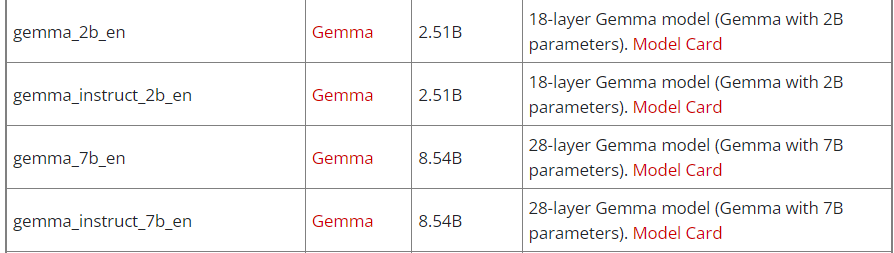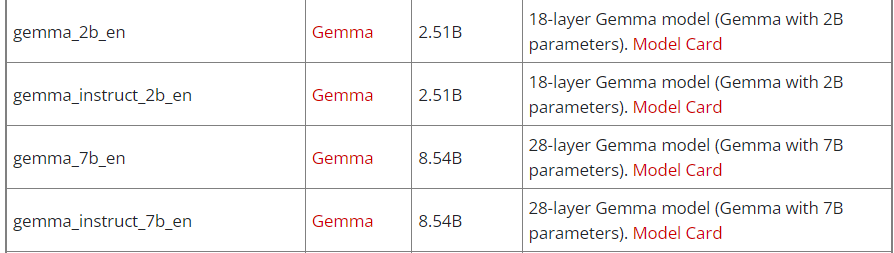

## Testing before fine-tuning

In [10]:
prompt = template.format(
    question="What is (are) Diabetes ?",
    answer="",
)
print(gemma_lm.generate(prompt, max_length=256))

I0000 00:00:1708788436.510120      27 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1708788436.573495      27 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1708788436.716571      27 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


Question:
What is (are) Diabetes ?

Answer:
Diabetes is a group of diseases that affect the way your body uses blood sugar (glucose). Glucose is a type of sugar that is found in the foods you eat. It is also made by your liver and pancreas.

Diabetes is a chronic disease that affects the way your body uses blood sugar. It is caused by a problem with the way your body makes or uses insulin. Insulin is a hormone that helps glucose enter your cells to be used for energy.

There are two main types of diabetes:

* Type 1 diabetes: This is when your body doesn't make enough insulin. It is also called insulin-dependent diabetes.
* Type 2 diabetes: This is when your body doesn't use insulin well. It is also called non-insulin-dependent diabetes.

Diabetes can be managed with diet, exercise, and medication.

Diabetes is a chronic disease that affects the way your body uses blood sugar. It is caused by a problem with the way your body makes or uses insulin. Insulin is a hormone that helps glucos

In [11]:
prompt = template.format(
    question="How to prevent Diabetes ?",
    answer="",
)
print(gemma_lm.generate(prompt, max_length=256))

Question:
How to prevent Diabetes ?

Answer:
Diabetes is a disease that affects the way your body uses sugar (glucose). It is caused by a lack of insulin, a hormone that helps glucose enter your cells.

The pancreas is a gland that produces insulin. When you eat, your body releases insulin to help glucose enter your cells. If you have diabetes, your body either doesn’t make enough insulin or doesn’t use it properly.

Diabetes is a chronic disease that can lead to serious health problems, including heart disease, stroke, kidney disease, and blindness.

There is no cure for diabetes, but there are many ways to manage it.

The best way to prevent diabetes is to eat a healthy diet, exercise regularly, and maintain a healthy weight.

If you have diabetes, it’s important to monitor your blood sugar levels and take your medications as prescribed.

If you have diabetes, it’s important to monitor your blood sugar levels and take your medications as prescribed.

If you have diabetes, it’s import

In [12]:
# Enable LoRA for the model and set the LoRA rank to 4.
gemma_lm.backbone.enable_lora(rank=4)
gemma_lm.summary()

Preprocessor: "gemma_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Tokenizer (type)                                   ┃                                             Vocab # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma_tokenizer (GemmaTokenizer)                   │                                             256,000 │
└────────────────────────────────────────────────────┴─────────────────────────────────────────────────────┘

Model: "gemma_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma_backbone                │ (None, None, 2048)        │   2,507,536,384 │ padding_mask[0][0],        │
│ (GemmaBackbone)               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 256000)      │     524,288,000 │ gemma_backbone[0][0]       │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,507,536,384 (9.34 GB)

 Trainable params: 1,363,968 (5.20 MB)

 Non-trainable params: 2,506,172,416 (9.34 GB)

In [13]:
# Limit the input sequence length to 512 (to control memory usage).
gemma_lm.preprocessor.sequence_length = 128
# Use AdamW (a common optimizer for transformer models).
optimizer = keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=0.01,
)
# Exclude layernorm and bias terms from decay.
optimizer.exclude_from_weight_decay(var_names=["bias", "scale"])

gemma_lm.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy()],
)
gemma_lm.fit(data, epochs=1, batch_size=1)

W0000 00:00:1708788489.286938      81 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


16412/16412 ━━━━━━━━━━━━━━━━━━━━ 3404s 205ms/step - loss: 1.3144 - sparse_categorical_accuracy: 0.6689


## Testing after tuning

In [14]:
prompt = template.format(
    question="What is (are) Diabetes ?",
    answer="",
)
print(gemma_lm.generate(prompt, max_length=256))

W0000 00:00:1708791881.174816      27 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1708791881.318224      27 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


Question:
What is (are) Diabetes ?

Answer:
Diabetes is a chronic illness that affects the body's ability to control blood sugar levels. People with diabetes cannot control their blood sugar levels, so they have a high risk of developing health problems, such as heart disease, kidney disease, nerve damage, vision problems, and stroke.
                
Diabetes is not one disease; it is a group of diseases. People with diabetes are diagnosed with one of the following diseases:
                
                - Type 1 diabetes. Type 1 diabetes is a chronic illness that occurs when the pancreas produces little or no insulin.


In [15]:
prompt = template.format(
    question="How to prevent Diabetes ?",
    answer="",
)
print(gemma_lm.generate(prompt, max_length=256))

Question:
How to prevent Diabetes ?

Answer:
The best way to prevent type 2 diabetes in adults is through healthy diet, regular exercise, and weight loss, and stopping smoking.
                
A healthy diet includes plenty of fruits, vegetables, and whole grains, along with low- or no-fat dairy products and lean meat. Eating a lot of red meat or processed meat raises your risk for heart disease and type 2 diabetes.
                
Exercise is another way to reduce the risk for type 2 diabetes. Exercise can help you lose weight and lower your blood pressure and blood sugar.


In [16]:
prompt = template.format(
    question="What's age range to get Diabetes ?",
    answer="",
)
print(gemma_lm.generate(prompt, max_length=128))

W0000 00:00:1708791913.175669      27 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


Question:
What's age range to get Diabetes ?

Answer:
The average age for a diagnosis of diabetes is age 45, but people of other ages also develop the disease. The risk of developing diabetes increases with age. The American Diabetes Association recommends people over age 50 should have an initial diagnosis of diabetes and be screened for diabetes every 3 to 5 years, depending on risk factors.
            
The National Diabetes Information Clearinghouse reports the following age-specific incidence and prevalence of diabetes for adults in the United States in 2006:
            
1.5%


In [17]:
gemma_lm.save("version_finetuned.keras")